In [1]:
%cd ..

/iacl/pg23/sam/medforj


/iacl/pg23/sam/software/miniconda3/envs/monai/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [39]:
%load_ext autoreload
%autoreload 2

In [40]:
# ===== Standard imports =====
import argparse
import numpy as np
import sys
import nibabel as nib
from pathlib import Path

# ===== Deep learning =====
import torch
from torch.amp import GradScaler, autocast
from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.utils import set_determinism

# ===== Project-specific imports =====
from medforj.scheduler import *
from medforj.plotting import *

In [12]:
def to_np(x):
    return x.detach().cpu().numpy().squeeze()

def sample(model, inferer, device, noise=None, verbose=True):
    with torch.inference_mode(), autocast(device_type="cuda", enabled=True):
        if noise is None:
            noise = torch.randn((1, 1, 192, 224, 192), device=device)
        img = inferer.sample(input_noise=noise, diffusion_model=model, verbose=verbose)
    return img.squeeze()

def to_nib_vol(x):
    """
    Convert the volumetric numpy array to a NIFTI1 Image
    with the correct affine and orientation.
    This also quantizes to 16-bit unsigned integer.
    """
    header = nib.Nifti1Header()
    header.set_data_shape(x.shape)
    header.set_data_dtype(np.uint16)
    header.set_zooms((1.0, 1.0, 1.0))
    header['descrip'] = "Synthetic image"

    affine = np.array([
        [-1, 0, 0, 0],
        [0, -1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

    int_x = ((x - x.min()) / (x.max() - x.min()) * (2**16 - 1)).astype(np.uint16)
    return nib.Nifti1Image(int_x, affine=affine, header=header)

In [5]:
device = torch.device(f"cuda:7")

model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    norm_num_groups=8,
    attention_levels=(False, False, False, False, True),
    num_res_blocks=2,
    num_head_channels=8,
).to(device)

In [30]:
weight_fpaths = [
    "/iacl/tms19/sam/epsilon_1x8x3_ema-100.pt",
    "/iacl/tms19/sam/flow_1x8x3_ema-100.pt",
    "/iacl/tms19/sam/velocity_1x8x3_ema-100.pt",
    "/iacl/tms19/sam/sample_1x8x3_ema-100.pt",
]

prediction_types = [
    "epsilon",
    "flow",
    "velocity",
    "sample",
]

In [31]:
imgs = []

for weight_fpath, prediction_type in zip(weight_fpaths, prediction_types):

    set_determinism(43)
    
    checkpoint_obj = torch.load(weight_fpath, weights_only=True, map_location=device)
    model.load_state_dict(checkpoint_obj['model'])
    
    scheduler = DDIMScheduler(
        num_train_timesteps=1000,
        prediction_type=prediction_type,
        clip_sample=True,
        clip_sample_min=-1,
        clip_sample_max=1,
    )
    scheduler.set_timesteps(num_inference_steps=64)
    inferer = DiffusionInferer(scheduler)
    
    img = to_np(sample(model, inferer, device, verbose=True))
    imgs.append(img)

100%|███████████████████████████████████████████████████████████████████████████████| 64/64 [01:59<00:00,  1.86s/it]


In [33]:
prediction_types

['epsilon', 'flow', 'velocity', 'sample']

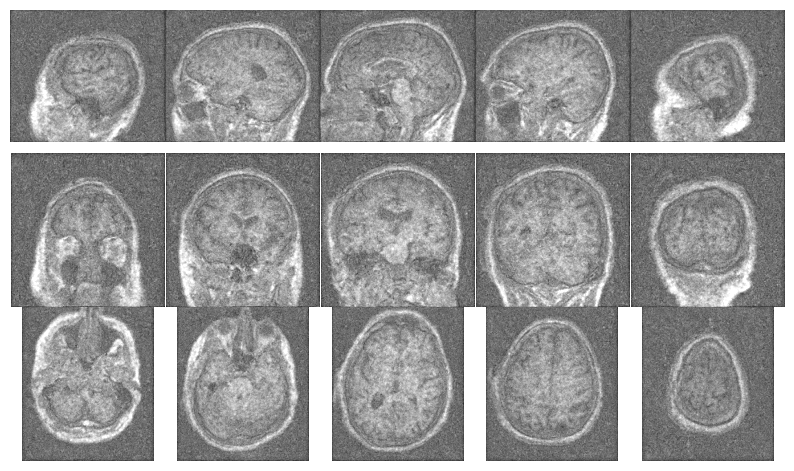

In [34]:
lightbox(imgs[0])

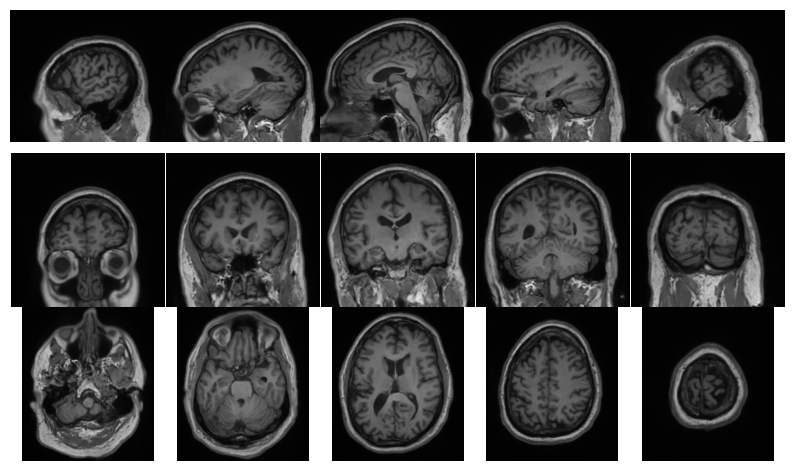

In [35]:
lightbox(imgs[1])

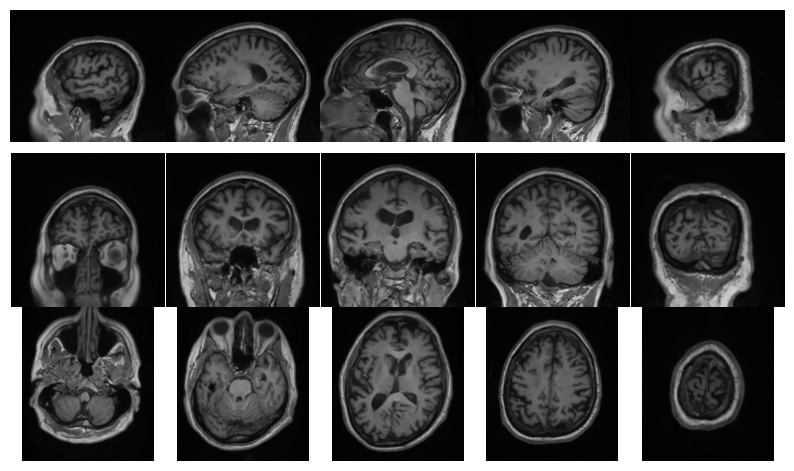

In [36]:
lightbox(imgs[2])

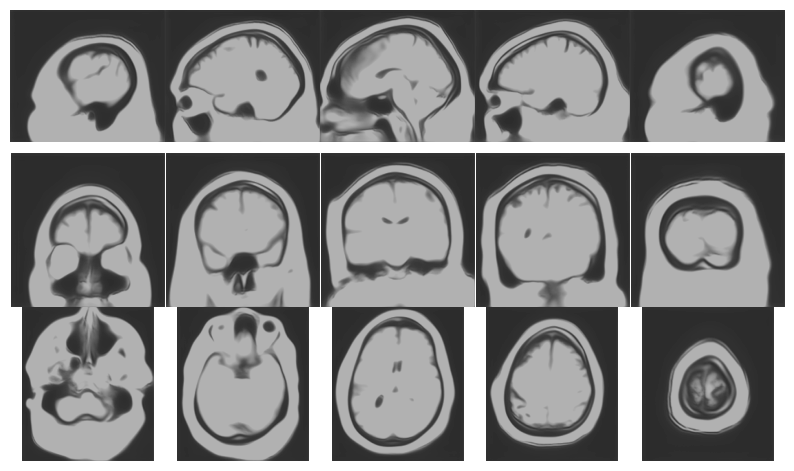

In [45]:
lightbox(imgs[3])

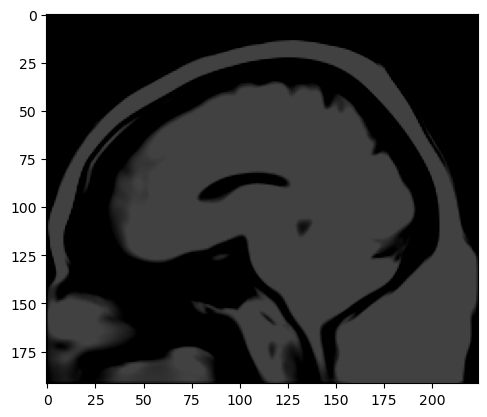

In [59]:
%matplotlib inline
plt.imshow(imgs[3][...,::-1][100].T, cmap='gray', vmin=0.3, vmax=3)
plt.show()

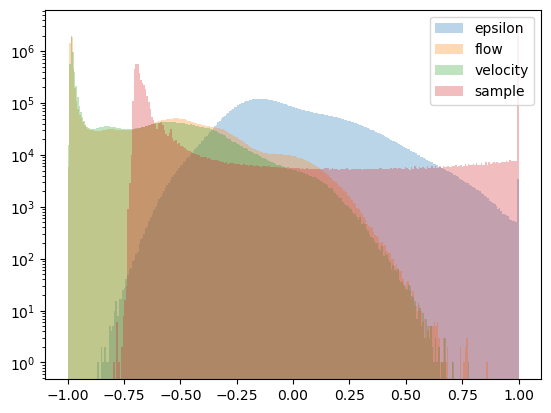

In [62]:
%matplotlib inline


for img, pred in zip(imgs, prediction_types):
    plt.hist(img.flatten(), bins=256, label=pred, alpha=0.3)

plt.yscale('log')
plt.legend()
plt.show()